# Lab 3 N Gram Models and Text Analysis

**Course:** ART1501 Natural Language Processing

This notebook completes every task in Lab 3 Part 1 and Part 2 using the three datasets specified in the manuals.

## Setup

In [1]:
%pip -q install pandas matplotlib nltk emoji kagglehub scikit-learn

In [2]:
from pathlib import Path
from collections import Counter
from itertools import chain, takewhile
import math
import re
import emoji
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
from nltk.lm import MLE
from nltk.lm.preprocessing import padded_everygram_pipeline
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Part 1 Generating Tweets Using N Grams

The Pakistan tweet data is cleaned by removing mentions, hashtags, `RT`, websites, emojis, extra symbols, and extra spaces. A bigram maximum likelihood estimation model is then trained and evaluated.

## Load the Pakistan Tweets Dataset

In [3]:
def get_dataset_file(slug, filename, candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    dataset_directory = Path(kagglehub.dataset_download(slug))
    return dataset_directory / filename

tweets_filename = 'Random Tweets from Pakistan- Cleaned- Anonymous.csv'
tweets_path = get_dataset_file(
    'adizafar/large-random-tweets-from-pakistan',
    tweets_filename,
    [
        Path(tweets_filename),
        Path('/content') / tweets_filename,
        Path('/kaggle/input/large-random-tweets-from-pakistan') / tweets_filename
    ]
)
tweets_df = pd.read_csv(
    tweets_path,
    encoding='utf-8',
    encoding_errors='ignore',
    low_memory=False
)
print(f'Rows: {len(tweets_df):,}')
print(f'Columns: {tweets_df.columns.tolist()}')
tweets_df.head()

Rows: 202,202
Columns: ['Unnamed: 0', 'created_at_tweet', 'full_text', 'retweet_count', 'favorite_count', 'reply_count', 'location', 'clean_text']


,Unnamed: 0,created_at_tweet,full_text,retweet_count,favorite_count,reply_count,location,clean_text
0,0,Wed Jul 03 07:20:15 +0000 2019,تیرا لیڈر میرا لیڈر نواز شریف نواز شریف❤️ کیا آپکا بھی ھے؟؟؟ @MaryamNSharif @Tanverhussan @SenPervaiz https://t.co/mDyOGs3sXv,226,1097,127,"Punjab, Pakistan",تیرا لیڈر میرا لیڈر نواز شریف نواز شریف کیا آپکا بھی ھے
1,1,Fri Jul 02 02:50:53 +0000 2021,"Happy birthday to my brother n boss , May you have many many more🎂🎂🎂, you are Gem 💎 #HappyBirthdayAtifRauf",54,273,9,"Punjab, Pakistan",happy birthday to my brother n boss may you have many many more you are gem
2,2,Fri Jul 02 12:12:53 +0000 2021,❤️❤️,50,131,13,"Punjab, Pakistan",
3,3,Tue Oct 15 22:29:16 +0000 2019,"`suspicious °jikook au jimin'in yaşadığı kasabada aniden başlayan cinayetler, onun kendisini sürekli takip eden yeni komşusu jungkook'tan şüphelenmesine neden olur https://t.co/QJA6XaDtVh",522,2134,86,"İstanbul, Türkiye",suspicious jikook au jimin'in yaşadığı kasabada aniden başlayan cinayetler onun kendisini sürekli takip eden yeni komşusu jungkook'tan şüphelenmesine neden olur
4,4,Wed May 13 04:34:31 +0000 2020,Speaking of @SpiderMan... 😂 https://t.co/uGJFiREUl8,74,535,11,Follow the ATP Tour ➡,speaking of


## Pre process the Tweets

In [4]:
def clean_tweet(text):
    text = emoji.replace_emoji(str(text).lower(), replace=' ')
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'\brt\b', ' ', text)
    text = re.sub(r"[^\w\s']", ' ', text, flags=re.UNICODE)
    text = re.sub(r'_+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

tweets_df['clean_text'] = tweets_df['full_text'].fillna('').map(clean_tweet)
tweet_tokens = [text.split() for text in tweets_df['clean_text'] if text]
tweet_tokens = [tokens for tokens in tweet_tokens if tokens]
print(f'Non-empty cleaned tweets: {len(tweet_tokens):,}')
print(f'Total tokens: {sum(map(len, tweet_tokens)):,}')
tweets_df[['full_text', 'clean_text']].head()

Non-empty cleaned tweets: 180,907
Total tokens: 3,099,309


,full_text,clean_text
0,تیرا لیڈر میرا لیڈر نواز شریف نواز شریف❤️ کیا آپکا بھی ھے؟؟؟ @MaryamNSharif @Tanverhussan @SenPervaiz https://t.co/mDyOGs3sXv,تیرا لیڈر میرا لیڈر نواز شریف نواز شریف کیا آپکا بھی ھے
1,"Happy birthday to my brother n boss , May you have many many more🎂🎂🎂, you are Gem 💎 #HappyBirthdayAtifRauf",happy birthday to my brother n boss may you have many many more you are gem
2,❤️❤️,
3,"`suspicious °jikook au jimin'in yaşadığı kasabada aniden başlayan cinayetler, onun kendisini sürekli takip eden yeni komşusu jungkook'tan şüphelenmesine neden olur https://t.co/QJA6XaDtVh",suspicious jikook au jimin'in yaşadığı kasabada aniden başlayan cinayetler onun kendisini sürekli takip eden yeni komşusu jungkook'tan şüphelenmesine neden olur
4,Speaking of @SpiderMan... 😂 https://t.co/uGJFiREUl8,speaking of


## Build the Bigram MLE Model

Training on all cleaned tweets can take approximately one minute, depending on the computer.

In [5]:
train_data, vocabulary_data = padded_everygram_pipeline(2, tweet_tokens)
bigram_model = MLE(2)
bigram_model.fit(train_data, vocabulary_data)
print(f'Model order: {bigram_model.order}')
print(f'Vocabulary size: {len(bigram_model.vocab):,}')

Model order: 2
Vocabulary size: 134,709


## Generate a Tweet

In [6]:
generated_words = bigram_model.generate(40, text_seed=['pakistan'], random_seed=42)
generated_words = list(takewhile(lambda word: word != '</s>', generated_words))
generated_tweet = 'pakistan ' + ' '.join(generated_words)
print(generated_tweet)

pakistan muhammad ahsan ali bairstow tom curran tom banton sam and disturbing several cases amp particularly in education minister recalled and technology news channel


## Required Counts Probabilities and Perplexity

The requested trigram value is calculated directly from the same cleaned corpus because a bigram model stores contexts of only one preceding word. Perplexity is calculated on the training corpus because unsmoothed MLE assigns zero probability to unseen held-out bigrams.

In [7]:
unigram_counts = Counter(chain.from_iterable(tweet_tokens))
bigram_counts = Counter()
trigram_counts = Counter()
for tokens in tweet_tokens:
    bigram_sequence = ['<s>'] + tokens + ['</s>']
    trigram_sequence = ['<s>', '<s>'] + tokens + ['</s>', '</s>']
    bigram_counts.update(zip(bigram_sequence, bigram_sequence[1:]))
    trigram_counts.update(zip(trigram_sequence, trigram_sequence[1:], trigram_sequence[2:]))

unigram_pakistan = unigram_counts['pakistan']
bigram_pakistan_is = bigram_counts[('pakistan', 'is')]
trigram_pakistan_is_a = trigram_counts[('pakistan', 'is', 'a')]
probability_pakistan_given_start = bigram_model.score('pakistan', ['<s>'])
probability_is_given_pakistan = bigram_model.score('is', ['pakistan'])
probability_a_given_pakistan_is = trigram_pakistan_is_a / bigram_pakistan_is
bigram_context_counts = Counter()
for (context, word), count in bigram_counts.items():
    bigram_context_counts[context] += count
total_bigram_events = sum(bigram_counts.values())
training_log_probability = sum(
    count * math.log(count / bigram_context_counts[context])
    for (context, word), count in bigram_counts.items()
)
training_perplexity = math.exp(-training_log_probability / total_bigram_events)
part1_results = pd.DataFrame({
    'Measure': [
        "Count of unigram 'pakistan'",
        "Count of bigram 'pakistan is'",
        "Count of trigram 'pakistan is a'",
        'P(pakistan | <s>)',
        'P(is | pakistan)',
        'P(a | pakistan is)',
        'Training perplexity'
    ],
    'Value': [
        unigram_pakistan,
        bigram_pakistan_is,
        trigram_pakistan_is_a,
        probability_pakistan_given_start,
        probability_is_given_pakistan,
        probability_a_given_pakistan_is,
        training_perplexity
    ]
})
part1_results

,Measure,Value
0,Count of unigram 'pakistan',13476.000000
1,Count of bigram 'pakistan is',697.000000
2,Count of trigram 'pakistan is a',70.000000
3,P(pakistan | <s>),0.007164
4,P(is | pakistan),0.051722
5,P(a | pakistan is),0.100430
6,Training perplexity,61.541746


# Part 2 Task 1 Text Analysis and NLP

The IMDB reviews are tokenized, converted to lowercase, cleaned of punctuation and HTML tags, and filtered using common English stop words.

## Define English Text Pre processing

In [8]:
contraction_fragments = {
    's', 't', 'don', 'didn', 'doesn', 'isn', 'wasn', 'weren', 'won',
    'wouldn', 'couldn', 'shouldn', 'haven', 'hasn', 'hadn', 'aren', 'ain',
    've', 'll', 're', 'd', 'm'
}
stop_words = set(ENGLISH_STOP_WORDS) | contraction_fragments

def preprocess_english_text(text):
    text = re.sub(r'<[^>]+>', ' ', str(text).lower())
    words = re.findall(r'[a-z]+', text)
    return [word for word in words if word not in stop_words and len(word) > 1]

## Load the IMDB Dataset

In [9]:
imdb_filename = 'IMDB Dataset.csv'
imdb_path = get_dataset_file(
    'lakshmi25npathi/imdb-dataset-of-50k-movie-reviews',
    imdb_filename,
    [
        Path(imdb_filename),
        Path('/content') / imdb_filename,
        Path('/kaggle/input/imdb-dataset-of-50k-movie-reviews') / imdb_filename
    ]
)
imdb_df = pd.read_csv(imdb_path)
print(f'Rows: {len(imdb_df):,}')
print(f'Columns: {imdb_df.columns.tolist()}')
imdb_df.head()

Rows: 50,000
Columns: ['review', 'sentiment', 'tokens']


,review,sentiment,tokens
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive,"[reviewers, mentioned, watching, just, oz, episode, hooked, right, exactly, happened, thing, struck, oz, brutality, unflinching, scenes, violence, set, right, word, trust, faint, hearted, timid, pulls, punches, regards, drugs, sex, violence, hardcore, classic, use, word, called, oz, nickname, given, oswald, maximum, security, state, penitentary, focuses, mainly, emerald, city, experimental, section, prison, cells, glass, fronts, face, inwards, privacy, high, agenda, em, city, home, aryans, muslims, gangstas, latinos, christians, italians, irish, scuffles, death, stares, dodgy, dealings, shady, agreements, far, away, say, main, appeal, fact, goes, shows, dare, forget, pretty, pictures, painted, mainstream, audiences, forget, charm, forget, romance, oz, mess, episode, saw, struck, nasty, ...]"
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive,"[wonderful, little, production, filming, technique, unassuming, old, time, bbc, fashion, gives, comforting, discomforting, sense, realism, entire, piece, actors, extremely, chosen, michael, sheen, got, polari, voices, pat, truly, seamless, editing, guided, references, williams, diary, entries, worth, watching, terrificly, written, performed, piece, masterful, production, great, 

## Calculate the Required IMDB Statistics

In [10]:
imdb_df['tokens'] = imdb_df['review'].map(preprocess_english_text)
total_reviews = len(imdb_df)
average_word_count = imdb_df['tokens'].map(len).mean()
reviews_with_good = imdb_df['tokens'].map(lambda tokens: 'good' in tokens).sum()
reviews_with_bad = imdb_df['tokens'].map(lambda tokens: 'bad' in tokens).sum()
word_frequencies = Counter(chain.from_iterable(imdb_df['tokens']))
top_words = pd.DataFrame(word_frequencies.most_common(15), columns=['Word', 'Frequency'])
imdb_results = pd.DataFrame({
    'Measure': [
        'Total number of reviews',
        'Average word count per preprocessed review',
        "Reviews containing 'good'",
        "Reviews containing 'bad'"
    ],
    'Value': [total_reviews, average_word_count, reviews_with_good, reviews_with_bad]
})
imdb_results

,Measure,Value
0,Total number of reviews,50000.00000
1,Average word count per preprocessed review,104.32482
2,Reviews containing 'good',19004.00000
3,Reviews containing 'bad',11788.00000


## Word Frequency Histogram

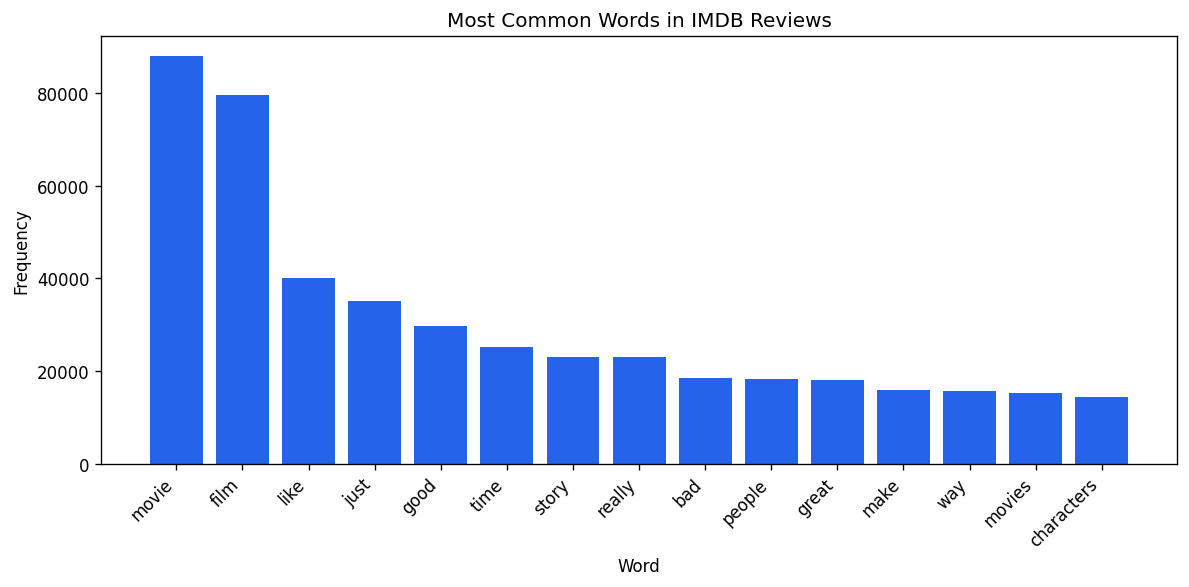

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(top_words['Word'], top_words['Frequency'], color='#2563eb')
plt.title('Most Common Words in IMDB Reviews')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Part 2 Task 2 N Gram Generation from Poem Data

The poem training data is cleaned using the same English preprocessing function. A `bigrams` column is created for every poem before the corpus-wide bigram frequencies are calculated.

## Load and Pre process the Poem Dataset

In [12]:
poem_filename = 'Poem_classification - train_data.csv'
poem_path = get_dataset_file(
    'ramjasmaurya/poem-classification-nlp',
    poem_filename,
    [
        Path(poem_filename),
        Path('/content') / poem_filename,
        Path('/kaggle/input/poem-classification-nlp') / poem_filename
    ]
)
poems_df = pd.read_csv(poem_path).dropna(subset=['Poem']).copy()
poems_df['tokens'] = poems_df['Poem'].map(preprocess_english_text)
poems_df['bigrams'] = poems_df['tokens'].map(lambda tokens: list(zip(tokens, tokens[1:])))
print(f'Poems used: {len(poems_df):,}')
poems_df[['Genre', 'Poem', 'tokens', 'bigrams']].head()

Poems used: 837


,Genre,Poem,tokens,bigrams
1,Music,"In the thick brushthey spend the hottest part of the day, soaking their hoovesin the trickle of mountain water the ravine hoardson behalf of the oleander.","[brushthey, spend, hottest, day, soaking, hoovesin, trickle, mountain, water, ravine, hoardson, behalf, oleander]","[(brushthey, spend), (spend, hottest), (hottest, day), (day, soaking), (soaking, hoovesin), (hoovesin, trickle), (trickle, mountain), (mountain, water), (water, ravine), (ravine, hoardson), (hoardson, behalf), (behalf, oleander)]"
2,Music,"Storms are generous. Something so easy to surrender to, sitting by the window, and then you step out into the garden you were so bored of,","[storms, generous, easy, surrender, sitting, window, step, garden, bored]","[(storms, generous), (generous, easy), (easy, surrender), (surrender, sitting), (sitting, window), (window, step), (step, garden), (garden, bored)]"
3,Music,"—After Ana Mendieta Did you carry around the matin star? Did you hold forest-fire in one hand? Would you wake to radiate, shimmer, gleam lucero-light? Through the morning would you measure the wingspan of an idea taking off— & by night would","[ana, mendieta, did, carry, matin, star, did, hold, forest, hand, wake, radiate, shimmer, gleam, lucero, light, morning, measure, wingspan, idea, taking, night]","[(ana, mendieta), (mendieta, did), (did, carry), (carry, matin), (matin, star), (star, did), (did, hold), (hold, forest), (forest, hand), (hand, wake), (wake, radiate), (radiate, shimmer), (shimmer, gleam), (gleam, lucero), (lucero, light), (light, morning), (morning, measure), (measure, wingspan), (wingspan, idea), (idea, taking), (taking, night)]"
4,Music,"for Aja Sherrard at 20The portent may itself be memory. —Wallace StevensHow hard to carry scores of adults on your back,not look at them as carrions of need, the distressof what loyalty requires. This pain is","[aja, sherrard, portent, memory, wallace, stevenshow, hard, carry, scores, adults, look, carrions, need, distressof, loyalty, requires, pain]","[(aja, sherrard), (sherrard, portent), (portent, memory), (memory, wallace), (wallace, stevenshow), (stevenshow, hard), (hard, carry), (carry, scores), (scores, adults), (adults, look), (look, carrions), (carrions, need), (need, distressof), (distressof, loyalty), (loyalty, requires), (requires, pain)]"
5,Music,"for Bob Marley, Bavaria, November 1980 Here is the brilliant morning on a fishing boat, this is the dream a dying man has in midwinter, the world covered in light and shadow—he dreams of St. Ann’s","[bob, marley, bavaria, november, brilliant, morning, fishing, boat, dream, dying, man, midwinter, world, covered, light, shadow, dreams, st, ann]","[(bob, marley), (marley, bavaria), (bavaria, november), (november, brilliant), (brilliant, morning), (morning, fishing), (fishing, boat), (boat, dream), (dream, dying), (dying, man), (man, midwinter), (midwinter, world), (world, covered), (covered, light), (light, shadow), (shadow, dreams), (dreams, st), (st, ann)]"


## Calculate and Display the Top 10 Bigrams

In [13]:
poem_bigram_frequencies = Counter(chain.from_iterable(poems_df['bigrams']))
top_poem_bigrams = pd.DataFrame(
    [(' '.join(words), frequency) for words, frequency in poem_bigram_frequencies.most_common(10)],
    columns=['Bigram', 'Frequency']
)
print(f'Total bigram occurrences: {sum(poem_bigram_frequencies.values()):,}')
print(f'Unique bigrams: {len(poem_bigram_frequencies):,}')
top_poem_bigrams

Total bigram occurrences: 18,986
Unique bigrams: 17,505


,Bigram,Frequency
0,ah yes,8
1,let say,6
2,parking lot,6
3,died august,5
4,did know,5
5,thou art,5
6,yes ah,5
7,dead man,4
8,river like,4
9,say did,4


# Final Results

**Part 1:** `pakistan` occurs **13,476** times, `pakistan is` occurs **697** times, and `pakistan is a` occurs **70** times. The training perplexity is **61.5417**.

**Part 2 Task 1:** The dataset contains **50,000 reviews**. The average is **104.3248 preprocessed words per review**. **19,004 reviews** contain `good`, and **11,788 reviews** contain `bad`.

**Part 2 Task 2:** The poem training data produces **18,986 bigram occurrences** and **17,505 unique bigrams**. The top 10 are displayed above.